# Delaunay Lowerstar filtrations

This filtration was introduced by [[Delaunay Bifiltrations of Functions on Point Clouds, Alonso et al]](https://doi.org/10.1137/1.9781611977912.173), whose code is available [here](https://bitbucket.org/mkerber/function_delaunay).

This bifiltration is very similar to the
[RipsLowerstar multifiltrations](rips.ipynb), and is more adapted to
low-dimensional Euclidean data.

## Definition

Let $X$ be a point cloud in $\mathbb R^n$, and $f\colon X\to \mathbb R$.

The CěchLowerstar bifiltration $F$ of the point cloud $X$ , with lowerstar function $f$ is the bifiltration over $\mathbb R_+\times \mathbb R$, given by:


\begin{align*}
\forall (r,d)\in \mathbb R_+\times \mathbb R,\quad&
F_{r,d} := \bigcup_{\substack{x\in X \\ f(x)\le d}} B(x,r)
\end{align*}


The DelaunayLowerstar bifiltration is a 1-critical bifiltration that is
topologically equivalent to this one; for the multicritical-to-one-critical
bridge, see the
[one-criticalification notebook](../ops/multicritical_free_implicit_resolution.ipynb).

## An example

In [1]:
import multipers as mp
import matplotlib.pyplot as plt

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/point_measure.py:202: SyntaxWarning: invalid escape sequence '\{'
  Zeros out the modules outside of \f$ \{ x\in \mathbb R^n \mid x \le \mathrm{mass_default}\}\f$.
/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/point_measure.py:228: SyntaxWarning: invalid escape sequence '\{'
  Zeros out the modules outside of \f$ \{ x\in \mathbb R^n \mid x \le \mathrm{mass_default}\}\f$.


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


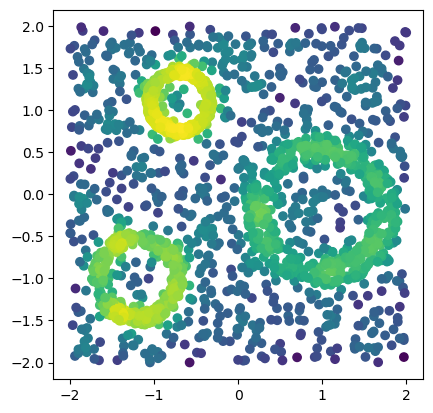

In [2]:
x = mp.data.three_annulus(1_000, 1_000)
f = - mp.filtrations.density.KDE(bandwidth=.1, return_log=True).fit(x).score_samples(x)
plt.scatter(*x.T, c = -f)
plt.gca().set_aspect(1)

The bifiltration can then be obtained by; the last cell below feeds it to the
[birth-curves notebook](../invariants/birth_curves.ipynb):

If only a given homological degree is necessary, this construction can made faster:

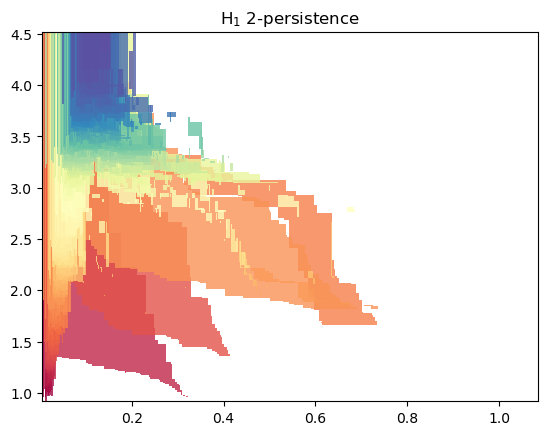

In [3]:
s = mp.filtrations.DelaunayLowerstar(points=x, function=f, reduce_degree=1)
mp.module_approximation(s).plot()

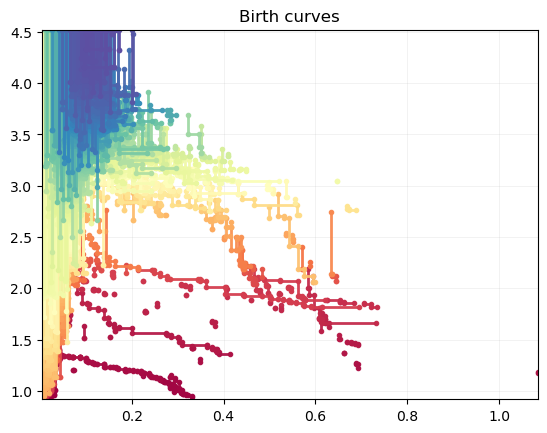

In [4]:
mp.invariants.birth_curves(s, plot=True);

## Autodiff

This bifiltration is not autodiff per se, but can be *weakenned* into a flag complex to be autodiff w.r.t. the initial point cloud, and the function $f$.

The gradient is only guaranteed almost everywhere, by [[Differentiability and Optimization of Multiparameter Persistent Homology]](https://proceedings.mlr.press/v235/scoccola24a.html).

In [5]:
import torch
y = torch.from_numpy(x).requires_grad_(True)
f = - mp.filtrations.density.KDE(bandwidth=.1, return_log=True).fit(y).score_samples(y)

In [8]:
st = mp.filtrations.DelaunayLowerstar(points=y, function=f, flagify=True)

Non-problematic operations, such as computing a
[minimal presentation](../ops/minimal_presentations_resolutions.ipynb), should
preserve gradient.

In [9]:
s = mp.Slicer(st).minpres(1)

and [invariants](../invariants/signed_measure.ipynb) should preserve the
gradient as well. See also the
[autodiff point-cloud notebook](../differentiability/rips_density_autodiff.ipynb).

True

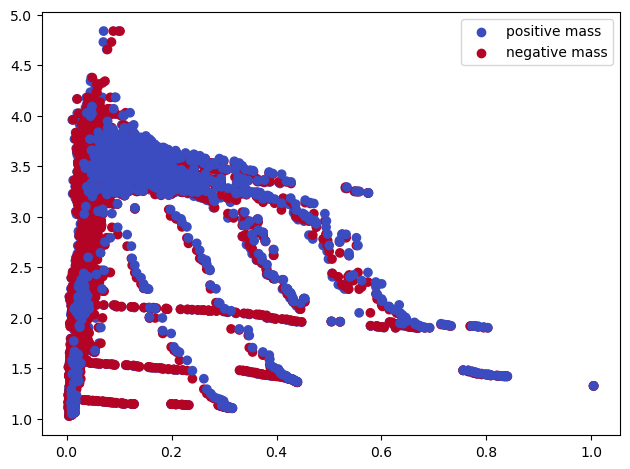

In [12]:
(pts,w), = mp.signed_measure(
    s,
    degree=1, 
    invariant="hilbert",
    plot=True
)
pts.requires_grad # Should be True